# NB04: Context-free Languages

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho



# 4.1 Context-free Languages

- *Context-free languages* are the second class in the Chomsky hierarchy
  - They strictly extend the expressive power of regular languages

- Regular languages are well suited for local patterns
  - fixed repetition
  - simple alternation
  - bounded memory

- But recognizing some languages require unbounded memory, for example:
  - "the same number of symbols" (e.g. $a^nb^n$)
  - nested or recursive structures (parentheses, blocks, expressions)

- These languages cannot be described by regular expressions (REs) nor finite automata (FAs)

- Instead, context-free languages are the languages recognized by **pushdown automata** (PDAs)
  - PDAs extend FAs with a symbol **stack**

- They are typically described formally by **context-free grammars** (CFGs)

- These languages play a central role in *syntactic analysis*
  - the syntax of most programming languages is context-free

- There exist languages that are not regular nor context-free
  - recognizing them requires more powerful models (e.g. Turing machines)
  - we will not go beyond context-free languages in these notes

## ✏️ Context-free language example: A language of nested parenthesis

- Consider a language that considers only `(` and `)` symbols

- Every opening `(` must be matched by a closing `)`

  - `(()())(())` ✅
  - `())` ❌
  - `()(()` ❌

- Can you think of an RE to recognize this language?

- Any proper computer language requires syntactic rules of this kind

- Rule description:
  - Any parenthesis that opens, must be eventually closed
  - We must somehow "memorize" how many parenthesis remain to be closed at each point

- How can we **formally specify** these rules?

- How can we **efficiently recognize** such valid inputs?

# 4.2 Context-free Grammars
   
- Context-free grammars (CFGs) provide a rule-based description of context-free languages

- They are mainly used in the specification of the the syntax of programming languages, enabling parsing and syntax tree construction


## Formal grammars

- A (formal) *grammar* consists of:
  - symbols we want to generate (terminals)
  - auxiliary symbols used during generation (nonterminals)
  - rules that rewrite nonterminals (productions)

- They are formal in contrast with natural language grammars


## ✏️ Grammar example: Bitstrings with at least one 1

```
S → A1A
A → A1
A → A0
A → ɛ
```

Or, grouping together production for the same nonterminal:

```
S → A1A
A → A1 | A0 | ɛ
```

## Definition: Grammar

- A *grammar* $G$ is a tuple $(\Sigma, N, P, S_0)$ where:
  - $\Sigma$ is the set of *terminal* symbols (the alphabet)
  - $N$ is a set of *nonterminal* symbols (the grammar's variables)
  - $P$ is a set of *productions* that state how nonterminal symbols can be expanded into sequences of terminal and nonterminal symbols
  - $S_0 \in N$ is the *start* symbol

## Derivations and parse trees

- A **derivation** is a sequence of applications of productions that expand nonterminals
  - One derivation step is denoted by $\Rightarrow$
  - Zero or more derivation steps are denoted by $\overset{*}{\Rightarrow}$

- We say that a derivation is *leftmost* / *rightmost* each step always expands the *leftmost* / *rightmost* nonterminal

- A word $w \in \Sigma^*$ (a sequence of terminal symbols) is **generated** by a grammar $G$ with start symbol $S$ if $S \overset{*}{\Rightarrow} w$

- A **parse tree** is a hierarchical representation of a derivation:
  - the root is the start symbol
  - internal nodes are nonterminals
  - leaves are terminals (or ε)
  - reading the leaves from left to right yields the derived word

- The set of words generated by a grammar defines a language

## ✏️ Derivation example: Bitstrings with at least one 1

- The grammar shown above has terminals $\Sigma = \{0,1\}$ and nonterminals $N = \{S,A\}$, with start symbol $S_0 = S$

- The productions $P$ are those already shown

```
S → A1A
A → A1 | A0 | ɛ
```


Is `0110` derivable by this grammar?

Leftmost derivation:

`S ⇒ A1A ⇒ A11A ⇒ A011A ⇒ ɛ011A ⇒ 011A0 ⇒ 011ɛ0 = 0110`

Since $S \overset{*}{\Rightarrow} 0110$ and $S$ is the start symbol, `0110` belongs to the language generated by the grammar.

## Regular grammars

- The regular languages that we have been expressing with REs can also be specified with formal grammars

- In particular, all regular languages can be generated by a *regular grammar*

- A regular grammar must follow these rules:
  - Only one nonterminal symbol on the left-hand side of productions
  - At most one nonterminal symbol in the right-hand side of productions, and always as the last symbol (or always as the first symbol)


## ✏️ Regular grammar example: Valid identifiers

Grammar with $\Sigma = \{ a, b, \ldots, Z, 0, \ldots, 9, \_ \}$, $N = \{ First, Rest \}$, $S_0 = First$, and the following productions:

```
First → aRest | bRest | ... | ZRest | _Rest
Rest  → aRest | bRest | ... | ZRest | _Rest | 0Rest | ... | 9Rest | ε
```


Word `fun32` can be derived as:

```
First ⇒ fRest ⇒ fuRest ⇒ funRest ⇒ fun3Rest ⇒ fun32Rest ⇒ fun32ɛ = fun32
```

Or constructing a parse tree:

```
                First
               /     \
              f      Rest
                    /    \
                   u     Rest
                        /    \
                       n     Rest
                            /    \
                           3     Rest
                                /    \
                               2     Rest
                                       \
                                        ɛ
```


## Context-free grammars

- *Context-free grammars* (CFGs) allow the specification of context-free languages

- They must follow this rule:
  - Every production only has one nonterminal symbol in the left-hand side

- This is why they are called context-free
  - A nonterminal can always be expanded by the same productions, regardless of the surrounding symbols

## ✏️ CFG example: A language of nested parenthesis

Grammar with $\Sigma = \{ (, ) \}$, $N = \{ S \}$, $S_0 = S$, and the following productions:

```
S → (S) | SS | ɛ
```

Word `(()(()))` can be (leftmost) derived as:

```
S ⇒ (S) ⇒ (SS) ⇒ ((S)S) ⇒ (()S) ⇒ (()(S)) ⇒ (()((S))) = (()(()))
```

Or constructing a parse tree:

```
       S
    /  |  \
   (   S   )
     /   \
    /     \
   S       S
 / | \   / | \
(  S  ) (  S  )
   |     / | \
   ɛ    (  S  )
           |
           ɛ
```

Or in a tree style that is to draw:
```
S
├── (
├── S
│   ├── S
│   │   ├── (
│   │   ├── S
│   │   │   └── ɛ
│   │   └── )
│   └── S
│       ├── (
│       ├── S
│       │   ├── (
│       │   ├── S
│       │   │   └── ɛ
│       │   └── )
│       └── )
└── )
```

## ✏️ CFG example: A language for arithmetic S-exprs

In [Lisp](https://en.wikipedia.org/wiki/Lisp_(programming_language))-style languages, S-exprs (symbolic expressions) represent computations using prefix notation and parentheses. In this notation:
  - The operator appears first, followed by its operands
  - Operands can be numbers or nested expressions

Example S-exprs:
  - `(+ 1 2)`
  - `(* 3 4)`
  - `(+ (* 2 3) 5)`
  - `(- (+ 4 5) (* 2 3))`



$\Sigma = \{ (,),+,-,*,/,0,1,\ldots,9 \}$, $N = \{ Expr, Op, Num, Dig \}$, $S_0 = Expr$
```
Expr → Num | ( Op Expr Expr )
Op   → + | - | * | /
Num  → Dig | Dig Num
Dig  → 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
```

Leftmost derivation of `(* ( + 2 3 ) 5 )`:

```
Expr ⇒ ( Op Expr Expr ) ⇒ ( * Expr Expr ) ⇒ (* ( Op Expr Expr ) Expr )
     ⇒ (* ( + Expr Expr ) Expr ) ⇒ (* ( + Num Expr ) Expr ) ⇒ (* ( + Dig Expr ) Expr )
     ⇒ (* ( + 2 Expr ) Expr ) ⇒ (* ( + 2 Num ) Expr ) ⇒ (* ( + 2 Dig ) Expr )
     ⇒ (* ( + 2 3 ) Expr ) ⇒ (* ( + 2 3 ) Num ) ⇒ (* ( + 2 3 ) Dig )
     ⇒ (* ( + 2 3 ) 5 )
```

Parse tree for `(* ( + 2 3 ) 5 )`:

```
Expr
├── (
├── Op
│   └── *
├── Expr
│   ├── (
│   ├── Op
│   │   └── +
│   ├── Expr
│   │   └── Num
│   │       └── Digit
│   │           └── 2
│   ├── Expr
│   │   └── Num
│   │       └── Digit
│   │           └── 3
│   └── )
├── Expr
│   └── Num
│       └── Digit
│           └── 4
└── )
```

## 🛠 CFG exercise: Language for arithmetic expressions

- Write a CFG to recognize standard arithmetic expressions over integer numbers
  - `(10 + 20) * 30` ✅
  - `10 + -20` ✅
  - `(10 + 20 * 30` ❌
  - `10 20 * 30` ❌
  - `10 + * 20` ❌

$\Sigma = \{ +, *, /, -, (, ), 0, 1, \dots, 9 \}$, $N = \{ Expr, Op, Num, Dig \}$, $S_0 = Expr$

```
Expr → Expr Op Expr | -Expr | (Expr) | Num
Op   → + | - | * | /
Num  → Dig | Dig Num
Dig  → 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
```

Leftmost derivation of `(2 + 3) * 5`:

```
Expr ⇒ Expr Op Expr ⇒ (Expr) Op Expr ⇒ (Expr Op Expr) Op Expr ⇒ (Num Op Expr) Op Expr
     ⇒ (Dig Op Expr) Op Expr ⇒ (2 Op Expr) Op Expr ⇒ (2 + Expr) Op Expr ⇒ (2 + Num) Op Expr
     ⇒ (2 + Dig) Op Expr ⇒ (2 + 3) Op Expr ⇒ (2 + 3) * Expr ⇒ (2 + 3) * Num ⇒ (2 + 3) * Dig
     ⇒ (2 + 3) * 5
```

Parse tree for `(2 + 3) * 5`:

```
Expr
├── Expr
│   ├── (
│   ├── Expr
│   │   ├── Expr
│   │   │   └── Num
│   │   │       └── Dig
│   │   │           └── 2
│   │   ├── Op
│   │   │   └── +
│   │   └── Expr
│   │       └── Num
│   │           └── Dig
│   │               └── 3
│   └── )
├── Op
│   └── *
└── Expr
    └── Num
        └── Dig
            └── 5
```

## Ambiguous grammars

- Let us get back to the language for nested parenthesis

- For many words, there are alternative derivations that give rise to different parse trees

- Two leftmost derivations and parse trees for `()()()`

    - `S ⇒ SS ⇒ (S)S ⇒ ()S ⇒ ()SS ⇒ ()(S)S ⇒ ()()S ⇒ ()()(S) ⇒ ()()()`

        ```
        S
        ├── S
        │   ├── (
        │   ├── S
        │   │   └── ε
        │   └── )
        └── S
            ├── S
            │   ├── (
            │   ├── S
            │   │   └── ε
            │   └── )
            └── S
                ├── (
                ├── S
                │   └── ε
                └── )
        ```
        
    - `S ⇒ SS ⇒ SSS ⇒ (S)SS ⇒ ()SS ⇒ ()(S)S ⇒ ()()S ⇒ ()()(S) ⇒ ()()()`

      ```
      S
      ├── S
      │   ├── S
      │   │   ├── (
      │   │   ├── S
      │   │   │   └── ε
      │   │   └── )
      │   └── S
      │       ├── (
      │       ├── S
      │       │   └── ε
      │       └── )
      └── S
          ├── (
          ├── S
          │   └── ε
          └── )
      ```



- When, for any word, there are two different leftmost (or rightmost) derivations, or two different parse trees, we say that the grammar is **ambiguous**

- Ambiguity does not affect the language generated by a grammar (the same set of words is derivable)

- But ambiguous grammars are unsuitable for syntactic analysis
  - The same program would have multiple valid meanings

- Often, ambiguous grammars can be rewritten into an equivalent unambiguous version
  - A version that generates the same set of words, but only with one parse tree for each word

- However, there are languages that are *inherently ambiguous*
  - There is no unambiguous grammar that generates such a language
  - E.g., $\{ a^ib^jc^k ∣ i=j \vee j=k, i,j,k>0 \}$

## ✏️ Ambiguity example: A language for nested parenthesis

- The following is an equivalent, but unambiguous, version of the nested parenthesis CFG:

  ```
  S → S(S) | ɛ
  ```

- Leftmost derivation of `()()()`:

  - `S ⇒ S(S) ⇒ S(S)(S) ⇒ S(S)(S)(S) ⇒ (S)(S)(S) ⇒ ()(S)(S) ⇒ ()()(S) ⇒ ()()()`

- Parse tree for `()()()`:

  ```
  S
  ├── S
  │   ├── S
  │   │   ├── S
  │   │   │   └── ε
  │   │   ├── (
  │   │   ├── S
  │   │   │   └── ε
  │   │   └── )
  │   ├── (
  │   ├── S
  │   │   └── ε
  │   └── )
  ├── (
  ├── S
  │   └── ε
  └── )
  ```

## 🛠 Ambiguity exercise: Language for arithmetic expressions

- The CFG presented above for arithmetic expressions is highly ambiguous

- Identify why, and rewrite the grammar to a unambiguous version


  - `1 + 2 * 3`
    ```
                  Expr
             /     |     \
         Expr      Op   Expr
       /  |  \     |     |
    Expr  Op  Expr *    Num
      |   |    |         |
     Num  +   Num       Dig
      |        |         |
     Dig      Dig        3
      |        |
      1        2
    ```

    ```
             Expr
        /     |     \
    Expr      Op    Expr
      |       |    /  |  \  
     Num      +  Expr Op Expr
      |           |   |    |
     Dig         Num  *   Num
      |           |        |
      1          Dig      Dig
                  |        |
                  2        3
    ```

- The issue here is the lack of *operator precedence* rules:
  - The first tree interprets as $(1 + 2) * 3 = 9$, the second $1 + (2 * 3) = 7$

- We can introduce new levels in the grammar to ensure that higher-precedence operators appear deeper in the parse tree

  ```
  Expr   → Expr AddOp Expr | Term
  Term   → Term MulOp Term | Factor
  AddOp  → + | -
  MulOp  → * | /
  Factor → -Factor | (Expr) | Num
  Num    → Dig | Dig Num
  Dig    → 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
  ```

- There is now a single interpretation for `1 + 2 * 3`

    ```
              Expr
          /     |     \
      Expr    AddOp    Expr
        |       |       |    
      Term      +      Term
        |           /   |   \
    Factor       Term MulOp Term
        |          |    |     |
       Num      Factor  *   Factor
        |          |          |
       Dig        Num        Num
        |          |          |
        1         Dig        Dig
                   |          |
                   2          3
    ```



  - `1 - 2 - 3`
    ```
                       Expr
                  /     |     \
              Expr    AddOp   Expr
            /  |  \     |      |
        Expr AddOp Expr -     Term
         |     |     |         |
        Term   -   Term      Factor
         |           |         |
      Factor        Factor    Num
         |           |         |
        Num         Num       Dig
         |           |         |
        Dig         Dig        3
         |           |
         1           2
    ```

    ```
                 Expr
            /     |     \
        Expr    AddOp    Expr
          |       |    /  |  \
        Term      - Expr AddOp Expr
          |         |     |     |
        Factor     Term   -    Term
          |         |           |
         Num      Factor      Factor
          |         |           |
         Dig       Num         Num
          |         |           |
          1        Dig         Dig
                    |           |
                    2           3
    ```

- The issue here is the lack of *associativity rules*:
  - The first tree interprets as $(1 - 2) - 3 = -4$, the second $1 - (2 - 3) = 0$

- We can control how recursion can be applied to force associativity rules

  ```
  Expr   → Expr AddOp Term | Term
  Term   → Term MulOp Factor | Factor
  Factor → -Factor | (Expr) | Num
  AddOp  → + | -
  MulOp  → * | /
  Num    → Dig Num | Dig
  Dig    → 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
  ```

- There is now a single interpretation for `1 - 2 - 3`

  ```
                   Expr
              /     |     \
          Expr    AddOp   Term
        /  |  \     |      |
    Expr AddOp Term -    Factor
      |    |     |         |
    Term   -   Factor     Num
      |          |         |
   Factor       Num       Dig
      |          |         |
     Num        Dig        3
      |          |
     Dig         2
      |           
      1           
  ```

# 4.3 CFG Recognition


## Automata-view of context-free languages

- Much like regular languages are recognized by FAs, context-free languages are recognized by *pushdown automata* (PDAs)

- PDAs extend FAs with an auxiliary *stack*

- This stack provides auxiliary memory, but can only be accessed in a last-in first-out manner


## Definition: PDA

- A (non-deterministic) pushdown automaton (PDA) is a tuple $(Q,\Sigma,\Gamma,\delta,q_i,Z_0,F)$
   * $Q$ is a finite set of states
   * $\Sigma$ is the input alphabet
   * $\Gamma$ is the stack alphabet
   * $\delta : Q \times \Sigma \cup \{\varepsilon\} \times \Gamma → \mathcal{P}(Q \times \Gamma^*)$ is a transition function
   * $q_i \in Q$ is the initial state
   * $Z_0 \in \Gamma$ is the initial stack symbol
   * $F \subseteq Q$ is a set of final (or accepting) states

- The transitions of a PDA read the top symbol of the stack, and add back a set of symbols

- A word $w \in \Sigma^*$ is processed by a PDA by successively applying $\delta$ to all the current states and symbols of $w$, starting in states $\{q_i\}$ and with a stack $Z_0$

- If one of the states reached after processing all symbols of $w$ is final, $w$ belongs to the language; otherwise, it does not
   - We call this this *acceptance by final state*

- Alternatively we can accept by *empty state*
  - In this case, final states are not considered, and a word is accepted if the stack is empty after processing the complete input

📌 Throughout the notebook, the [`automata`](https://caleb531.github.io/automata/) Python module is used to draw and manipulate automata. This is not part of the syllabus.

## ✏️ PDA example: A language of nested parenthesis

- Use the stack to memorize every open parenthesis

- When a closing parenthesis is seen, pop from the stack (if possible)

- If the bottom of the stack is seen, try to accept

In [ ]:
# libraries to allow the visualization and manipulation of automata
!apt-get update -qq
!apt-get install -y -qq graphviz graphviz-dev
!pip install -q pygraphviz coloraide
!pip install -q automata-lib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatk1.0-data.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previou

- The following (non-deterministic) PDA accepts by final state

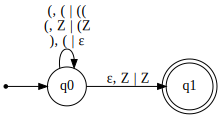

In [ ]:
from automata.pda.npda import NPDA

NPDA(
    states={"q0", "q1"},
    input_symbols={"(", ")"},
    stack_symbols={"Z", "("},
    transitions={
        "q0": {
            "(": { "Z": {("q0", "(Z")}, "(": {("q0", "((")}  },
            ")": { "(": {("q0", "")} },
            "": { "Z": {("q1", "Z")} } } },
    initial_state="q0",
    initial_stack_symbol="Z",
    final_states={"q1"},
    acceptance_mode="final_state").show_diagram(path = None)

- Alternatively, the following (non-deterministic) PDA accepts by empty stack

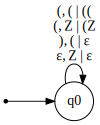

In [ ]:
from automata.pda.npda import NPDA

NPDA(
    states={"q0"},
    input_symbols={"(", ")"},
    stack_symbols={"Z", "("},
    transitions={
        "q0": {
            "(": { "Z": {("q0", "(Z")}, "(": {("q0", "((")}  },
            ")": { "(": {("q0", "")} },
            "": { "Z": {("q0", "")} } } },
    initial_state="q0",
    initial_stack_symbol="Z",
    final_states=set(),
    acceptance_mode="empty_stack").show_diagram(path = None)

## CFG and PDA equivalence

- The CFGs and (non-deterministic) PDAs are equivalent
  - A CFG can be converted into a PDA automatically, and vice-versa

- Context-free languages are exactly those that can be described by a CFG or a non-deterministic PDA

- Note that, unlike FAs, non-deterministic PDAs and deterministic PDAs are not equivalent formalisms
  - Deterministic PDAs can only recognize a subset of context-free languages

## Performance of membership tests

- Naively testing the membership for a word $w$ in a context-free language may be exponential in the worst case
  - For instance, directly executing a non-deterministic PDA

- However, there are algorithms that can test membership in $O(n^3)$ time in the worst case
  - Cocke–Younger–Kasami (CYK) algorithm
  - Earley algorithm

- More efficient, linear algorithms exist for **subsets** of CFGs
  - We will focus a subset of context-free languages that can be recognized by *deterministic* PDAs
  - Programming languages in general fall in this subset

-- Nuno Macedo, 2026-03-10